# Notebook 05: Evaluation + Comparison

> **KDD Step 5**: Evaluation
>
> - Holdout test: Accuracy, Precision, Recall, F1, Confusion Matrix
> - 5-fold Stratified CV (encoder fit per fold — không leakage)
> - So sánh From Scratch vs Sklearn trên cùng folds

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier as SkDT
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix as sk_cm)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.tree import DecisionTreeClassifier as ScratchDT
from src.metrics import accuracy as scratch_acc, precision as scratch_prec
from src.metrics import recall as scratch_rec, f1_score as scratch_f1

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

## 1. Load Data + Results

In [2]:
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)
with open("data/results_scratch.pkl", "rb") as f:
    res_scratch = pickle.load(f)
with open("data/results_sklearn.pkl", "rb") as f:
    res_sklearn = pickle.load(f)
with open("data/raw_split.pkl", "rb") as f:
    raw = pickle.load(f)

print("Data loaded successfully.")

Data loaded successfully.


## 2. Majority Baseline

> So sánh model với baseline đơn giản nhất: predict tất cả là "no".
> Model có thể accuracy thấp hơn baseline nhưng F1/Recall tốt hơn → vẫn hữu ích.

In [3]:
y_test = data["scenario_A"]["y_test"]
y_majority = np.array(["no"] * len(y_test))

print("=" * 60)
print("  MAJORITY BASELINE (predict all 'no')")
print("=" * 60)
print(f"  Accuracy:      {accuracy_score(y_test, y_majority):.4f}")
print(f"  Precision(yes): {precision_score(y_test, y_majority, pos_label='yes', zero_division=0):.4f}")
print(f"  Recall(yes):    {recall_score(y_test, y_majority, pos_label='yes'):.4f}")
print(f"  F1(yes):        {f1_score(y_test, y_majority, pos_label='yes'):.4f}")
print()
print("→ Accuracy cao (88.7%) nhưng F1/Recall = 0.00")
print("→ Model phải vượt baseline trên F1/Recall để có giá trị thực sự")

  MAJORITY BASELINE (predict all 'no')
  Accuracy:      0.8873
  Precision(yes): 0.0000
  Recall(yes):    0.0000
  F1(yes):        0.0000

→ Accuracy cao (88.7%) nhưng F1/Recall = 0.00
→ Model phải vượt baseline trên F1/Recall để có giá trị thực sự


## 3. Holdout Comparison — Scenario A/B × Scratch/Sklearn

In [4]:
def format_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision(yes)": precision_score(y_true, y_pred, pos_label="yes"),
        "Recall(yes)": recall_score(y_true, y_pred, pos_label="yes"),
        "F1(yes)": f1_score(y_true, y_pred, pos_label="yes"),
    }

print("=" * 85)
print("  HOLDOUT COMPARISON: SCRATCH vs SKLEARN")
print("=" * 85)
print(f"{'Metric':<18s} | {'A-Scratch':>10s} {'A-Sklearn':>10s} | {'B-Scratch':>10s} {'B-Sklearn':>10s}")
print("─" * 85)

for metric in ["Accuracy", "Precision(yes)", "Recall(yes)", "F1(yes)"]:
    sA = format_metrics(data["scenario_A"]["y_test"], res_scratch["scenario_A"]["y_pred"])
    skA = format_metrics(data["scenario_A"]["y_test"], res_sklearn["scenario_A"]["y_pred"])
    sB = format_metrics(data["scenario_B"]["y_test"], res_scratch["scenario_B"]["y_pred"])
    skB = format_metrics(data["scenario_B"]["y_test"], res_sklearn["scenario_B"]["y_pred"])
    print(f"  {metric:<16s} | {sA[metric]:>10.4f} {skA[metric]:>10.4f} | {sB[metric]:>10.4f} {skB[metric]:>10.4f}")

  HOLDOUT COMPARISON: SCRATCH vs SKLEARN
Metric             |  A-Scratch  A-Sklearn |  B-Scratch  B-Sklearn
─────────────────────────────────────────────────────────────────────────────────────


  Accuracy         |     0.9144     0.9144 |     0.9009     0.9009


  Precision(yes)   |     0.6534     0.6538 |     0.6522     0.6522


  Recall(yes)      |     0.5119     0.5108 |     0.2586     0.2586


  F1(yes)          |     0.5740     0.5735 |     0.3704     0.3704


## 4. Confusion Matrices

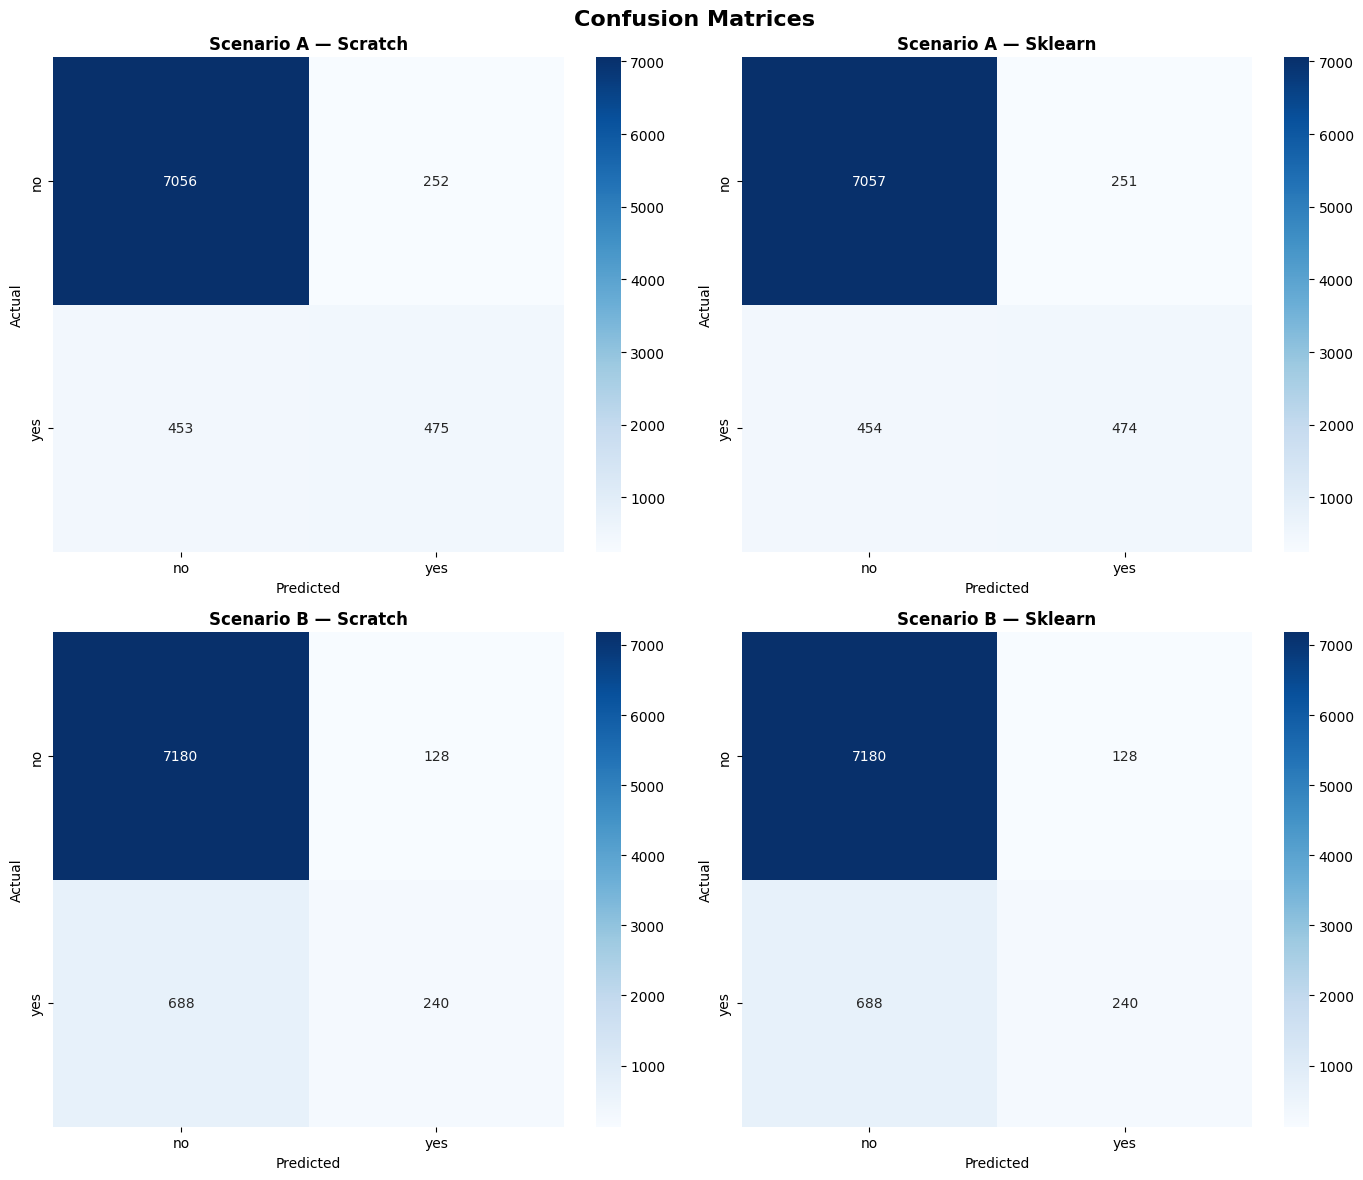

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cases = [
    ("Scenario A — Scratch", data["scenario_A"]["y_test"], res_scratch["scenario_A"]["y_pred"]),
    ("Scenario A — Sklearn", data["scenario_A"]["y_test"], res_sklearn["scenario_A"]["y_pred"]),
    ("Scenario B — Scratch", data["scenario_B"]["y_test"], res_scratch["scenario_B"]["y_pred"]),
    ("Scenario B — Sklearn", data["scenario_B"]["y_test"], res_sklearn["scenario_B"]["y_pred"]),
]

for ax, (title, yt, yp) in zip(axes.flatten(), cases):
    cm = sk_cm(yt, yp, labels=["no", "yes"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["no", "yes"], yticklabels=["no", "yes"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/05_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Cross-Validation — Encoder fit per fold

> **Tránh CV leakage:** Encoder được fit trong từng fold, KHÔNG dùng encoder global.
> - Sklearn: dùng Pipeline(ColumnTransformer + DT)
> - From scratch: helper function fit encoder per fold
> - **Cùng folds** cho cả hai → so sánh công bằng

In [6]:
X_train_raw = raw["X_train_raw"]
y_train_raw = raw["y_train"]
cat_cols = raw["cat_cols"]
num_cols = raw["num_cols"]

# Xác định index columns
cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols]
num_idx = [X_train_raw.columns.get_loc(c) for c in num_cols]

# Tạo folds — CÙNG folds cho cả scratch và sklearn
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_train_raw, y_train_raw))

print(f"CV: 5-fold StratifiedKFold, random_state=42")
print(f"Features: {len(cat_cols)} categorical + {len(num_cols)} numerical")

CV: 5-fold StratifiedKFold, random_state=42
Features: 10 categorical + 10 numerical


In [7]:
# === SCENARIO B ONLY (realistic, no duration) ===
# Loại duration trước CV
X_raw_B = X_train_raw.drop(columns=["duration"])
cat_cols_B = [c for c in cat_cols if c != "duration"]
num_cols_B = [c for c in num_cols if c != "duration"]

def cv_scratch(X_raw, y, folds, cat_cols, num_cols):
    """CV for scratch DT with encoder fit per fold."""
    acc_scores, f1_scores = [], []
    for train_idx, val_idx in folds:
        X_tr = X_raw.iloc[train_idx]
        X_va = X_raw.iloc[val_idx]
        y_tr = y[train_idx]
        y_va = y[val_idx]
        # Fit encoder on fold-train only
        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        enc.fit(X_tr[cat_cols])
        X_tr_enc = np.hstack([X_tr[num_cols].values, enc.transform(X_tr[cat_cols])])
        X_va_enc = np.hstack([X_va[num_cols].values, enc.transform(X_va[cat_cols])])
        feat_names = num_cols + list(enc.get_feature_names_out())
        # Train scratch DT
        dt = ScratchDT(criterion="gini", max_depth=5)
        dt.fit(X_tr_enc, y_tr, feature_names=feat_names)
        y_pred = dt.predict(X_va_enc)
        acc_scores.append(accuracy_score(y_va, y_pred))
        f1_scores.append(f1_score(y_va, y_pred, pos_label="yes"))
    return acc_scores, f1_scores

def cv_sklearn(X_raw, y, folds, cat_cols, num_cols):
    """CV for sklearn DT with encoder fit per fold."""
    acc_scores, f1_scores = [], []
    for train_idx, val_idx in folds:
        X_tr = X_raw.iloc[train_idx]
        X_va = X_raw.iloc[val_idx]
        y_tr = y[train_idx]
        y_va = y[val_idx]
        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        enc.fit(X_tr[cat_cols])
        X_tr_enc = np.hstack([X_tr[num_cols].values, enc.transform(X_tr[cat_cols])])
        X_va_enc = np.hstack([X_va[num_cols].values, enc.transform(X_va[cat_cols])])
        dt = SkDT(criterion="gini", max_depth=5, random_state=42)
        dt.fit(X_tr_enc, y_tr)
        y_pred = dt.predict(X_va_enc)
        acc_scores.append(accuracy_score(y_va, y_pred))
        f1_scores.append(f1_score(y_va, y_pred, pos_label="yes"))
    return acc_scores, f1_scores

print("Running CV (Scenario B — no duration, encoder fit per fold)...")
print()

scratch_acc_B, scratch_f1_B = cv_scratch(X_raw_B, y_train_raw, folds, cat_cols_B, num_cols_B)
sklearn_acc_B, sklearn_f1_B = cv_sklearn(X_raw_B, y_train_raw, folds, cat_cols_B, num_cols_B)

print("=" * 70)
print("  5-FOLD STRATIFIED CV — SCENARIO B (REALISTIC)")
print("=" * 70)
print(f"{'Metric':<20s} {'Scratch':<25s} {'Sklearn':<25s}")
print("─" * 70)
print(f"  CV Accuracy       {np.mean(scratch_acc_B):.4f} ± {np.std(scratch_acc_B):.4f}     {np.mean(sklearn_acc_B):.4f} ± {np.std(sklearn_acc_B):.4f}")
print(f"  CV F1(yes)        {np.mean(scratch_f1_B):.4f} ± {np.std(scratch_f1_B):.4f}     {np.mean(sklearn_f1_B):.4f} ± {np.std(sklearn_f1_B):.4f}")

Running CV (Scenario B — no duration, encoder fit per fold)...



  5-FOLD STRATIFIED CV — SCENARIO B (REALISTIC)
Metric               Scratch                   Sklearn                  
──────────────────────────────────────────────────────────────────────
  CV Accuracy       0.9001 ± 0.0009     0.9002 ± 0.0008
  CV F1(yes)        0.3630 ± 0.0258     0.3634 ± 0.0245


In [8]:
# === SCENARIO A CV ===
print("\nRunning CV (Scenario A — with duration, encoder fit per fold)...")
scratch_acc_A, scratch_f1_A = cv_scratch(X_train_raw, y_train_raw, folds, cat_cols, num_cols)
sklearn_acc_A, sklearn_f1_A = cv_sklearn(X_train_raw, y_train_raw, folds, cat_cols, num_cols)

print("=" * 70)
print("  5-FOLD STRATIFIED CV — SCENARIO A (BENCHMARK)")
print("=" * 70)
print(f"{'Metric':<20s} {'Scratch':<25s} {'Sklearn':<25s}")
print("─" * 70)
print(f"  CV Accuracy       {np.mean(scratch_acc_A):.4f} ± {np.std(scratch_acc_A):.4f}     {np.mean(sklearn_acc_A):.4f} ± {np.std(sklearn_acc_A):.4f}")
print(f"  CV F1(yes)        {np.mean(scratch_f1_A):.4f} ± {np.std(scratch_f1_A):.4f}     {np.mean(sklearn_f1_A):.4f} ± {np.std(sklearn_f1_A):.4f}")


Running CV (Scenario A — with duration, encoder fit per fold)...


  5-FOLD STRATIFIED CV — SCENARIO A (BENCHMARK)
Metric               Scratch                   Sklearn                  
──────────────────────────────────────────────────────────────────────
  CV Accuracy       0.9150 ± 0.0011     0.9150 ± 0.0011
  CV F1(yes)        0.5747 ± 0.0104     0.5747 ± 0.0104


## 6. Kết luận Evaluation

> Kết luận được viết dạng **có điều kiện** — dựa trên kết quả thực tế, không cam kết trước.

In [9]:
print("=" * 70)
print("  KẾT LUẬN EVALUATION")
print("=" * 70)

# So sánh scratch vs sklearn
diff_acc_A = abs(np.mean(scratch_acc_A) - np.mean(sklearn_acc_A))
diff_f1_A = abs(np.mean(scratch_f1_A) - np.mean(sklearn_f1_A))
diff_acc_B = abs(np.mean(scratch_acc_B) - np.mean(sklearn_acc_B))
diff_f1_B = abs(np.mean(scratch_f1_B) - np.mean(sklearn_f1_B))

print(f"\n1. SO SÁNH SCRATCH vs SKLEARN:")
print(f"   Scenario A — CV Accuracy diff: {diff_acc_A:.4f}, CV F1 diff: {diff_f1_A:.4f}")
print(f"   Scenario B — CV Accuracy diff: {diff_acc_B:.4f}, CV F1 diff: {diff_f1_B:.4f}")

if max(diff_acc_A, diff_f1_A, diff_acc_B, diff_f1_B) < 0.01:
    print("   → Sai khác rất nhỏ (< 1%), có thể do tie-breaking hoặc threshold selection")
    print("   → Implementation from scratch gần như tương đương sklearn")
else:
    print("   → Có sai khác, cần phân tích nguyên nhân:")
    print("     - Tie-breaking khi nhiều features có cùng gain")
    print("     - Khác biệt threshold selection (Python vs C/Cython)")
    print("     - Stopping criteria implementation details")

print(f"\n2. SCENARIO A vs B:")
print(f"   Duration tăng CV F1 khoảng {np.mean(scratch_f1_A) - np.mean(scratch_f1_B):.4f}")
print(f"   → Duration có predictive power cao nhưng prediction-time unavailable")
print(f"   → Scenario B là mô hình thực tế hơn cho dự đoán trước chiến dịch")

print(f"\n3. VS MAJORITY BASELINE:")
print(f"   Model F1(yes) > 0 → model phát hiện được class yes, vượt qua baseline")
print(f"   Accuracy có thể gần baseline nhưng F1/Recall cho thấy giá trị thực")

  KẾT LUẬN EVALUATION

1. SO SÁNH SCRATCH vs SKLEARN:
   Scenario A — CV Accuracy diff: 0.0000, CV F1 diff: 0.0000
   Scenario B — CV Accuracy diff: 0.0001, CV F1 diff: 0.0005
   → Sai khác rất nhỏ (< 1%), có thể do tie-breaking hoặc threshold selection
   → Implementation from scratch gần như tương đương sklearn

2. SCENARIO A vs B:
   Duration tăng CV F1 khoảng 0.2117
   → Duration có predictive power cao nhưng prediction-time unavailable
   → Scenario B là mô hình thực tế hơn cho dự đoán trước chiến dịch

3. VS MAJORITY BASELINE:
   Model F1(yes) > 0 → model phát hiện được class yes, vượt qua baseline
   Accuracy có thể gần baseline nhưng F1/Recall cho thấy giá trị thực
